# Lista de Exercícios 3 — Mapas Auto-Organizáveis (SOM)
## Aplicação: Diagnóstico de Doenças da Tireoide

Nesta lista de exercícios, você fará uma exploração empírica profunda dos **hiperparâmetros** do Mapa Auto-Organizável (SOM). A ideia é testar os efeitos de cada parâmetro de forma isolada, culminando na montagem da melhor configuração possível para resolver um problema real de classificação médica.

**Base de Dados (`c_thyroid.csv`):**
A base de dados contém pacientes classificados em 3 condições da tireoide (coluna `target`):
* `1.0`: Normal
* `2.0`: Hipertireoidismo
* `3.0`: Hipotireoidismo

---
### Preparação do Ambiente
Copie a classe `SelfOrganizingMap` completa do notebook anterior (SOM - Hands-on) e execute-a na célula abaixo. Importe também as bibliotecas necessárias.


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import defaultdict, Counter
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')

class SelfOrganizingMap:
    """
    Implementacao completa de um Mapa Auto-Organizavel (SOM) em PyTorch.
    Suporta topologias retangular e hexagonal, multiplas funcoes de
    vizinhanca e decaimento, e visualizacoes profissionais.
    """

    def __init__(self, m, n, input_dim, topology='rectangular',
                 neighborhood_fn='gaussian', decay_fn='exponential',
                 init_method='pca', random_seed=42):
        self.m = m
        self.n = n
        self.input_dim = input_dim
        self.topology = topology
        self.neighborhood_fn_name = neighborhood_fn
        self.decay_fn_name = decay_fn
        self.init_method = init_method
        self.n_neurons = m * n

        torch.manual_seed(random_seed)
        np.random.seed(random_seed)

        self.grid_positions = self._compute_grid_positions()
        self.pairwise_distances = torch.cdist(
            self.grid_positions.unsqueeze(0),
            self.grid_positions.unsqueeze(0)
        ).squeeze(0)

        self.weights = None
        self._total_iterations = 0
        self.history = {
            'iteration': [], 'qe': [], 'te': [], 'lr': [], 'sigma': []
        }
        self.phase_boundaries = []

    # ═══════════ TOPOLOGY ═══════════

    def _compute_grid_positions(self):
        positions = torch.zeros(self.n_neurons, 2)
        for i in range(self.m):
            for j in range(self.n):
                k = i * self.n + j
                if self.topology == 'hexagonal':
                    positions[k, 0] = j + 0.5 * (i % 2)
                    positions[k, 1] = i * np.sqrt(3) / 2
                else:
                    positions[k, 0] = float(j)
                    positions[k, 1] = float(i)
        return positions

    def _get_neighbors(self, idx):
        i = idx // self.n
        j = idx % self.n
        neighbors = []
        if self.topology == 'rectangular':
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < self.m and 0 <= nj < self.n:
                    neighbors.append(ni * self.n + nj)
        else:
            if i % 2 == 0:
                offsets = [(-1, -1), (-1, 0), (0, -1), (0, 1), (1, -1), (1, 0)]
            else:
                offsets = [(-1, 0), (-1, 1), (0, -1), (0, 1), (1, 0), (1, 1)]
            for di, dj in offsets:
                ni, nj = i + di, j + dj
                if 0 <= ni < self.m and 0 <= nj < self.n:
                    neighbors.append(ni * self.n + nj)
        return neighbors

    def _neuron_xy(self, k):
        """Coordenadas (x, y) do neuronio k na grade."""
        i, j = k // self.n, k % self.n
        if self.topology == 'hexagonal':
            return j + 0.5 * (i % 2), i * np.sqrt(3) / 2
        return float(j), float(i)

    def _hex_vertices(self, cx, cy):
        """Vertices de um hexagono pointy-top centrado em (cx, cy).

        Para a grade com espacamento horizontal = 1 e vertical = sqrt(3)/2,
        o raio circunscrito eh R = 1/sqrt(3).  Os vertices ficam em angulos
        30, 90, 150, 210, 270, 330 graus, o que produz arestas verticais
        entre vizinhos horizontais e encaixe perfeito na grade offset.
        """
        R = 1.0 / np.sqrt(3)
        angles = [np.pi / 6 + k * np.pi / 3 for k in range(6)]
        return [(cx + R * np.cos(a), cy + R * np.sin(a)) for a in angles]

    # ═══════════ INITIALIZATION ═══════════

    def initialize(self, data):
        if self.init_method == 'pca':
            self._init_weights_pca(data)
        else:
            self._init_weights_random(data)

    def _init_weights_random(self, data):
        lo = data.min(dim=0).values
        hi = data.max(dim=0).values
        self.weights = lo + torch.rand(self.n_neurons, self.input_dim) * (hi - lo)

    def _init_weights_pca(self, data):
        mean = data.mean(dim=0)
        centered = data - mean
        cov = (centered.T @ centered) / (len(data) - 1)
        eigenvalues, eigenvectors = torch.linalg.eigh(cov)
        idx = torch.argsort(eigenvalues, descending=True)
        eigenvalues = eigenvalues[idx].clamp(min=0)
        eigenvectors = eigenvectors[:, idx]
        pc1 = eigenvectors[:, 0]
        pc2 = eigenvectors[:, 1] if self.input_dim >= 2 else torch.zeros_like(pc1)
        self.weights = torch.zeros(self.n_neurons, self.input_dim)
        for k in range(self.n_neurons):
            c1 = (2.0 * (k // self.n) / max(self.m - 1, 1)) - 1.0
            c2 = (2.0 * (k % self.n) / max(self.n - 1, 1)) - 1.0
            self.weights[k] = (mean
                               + c1 * torch.sqrt(eigenvalues[0]) * pc1
                               + c2 * torch.sqrt(eigenvalues[1]) * pc2)

    # ═══════════ NEIGHBORHOOD ═══════════

    def _neighborhood(self, bmu_idx, sigma):
        d = self.pairwise_distances[bmu_idx]
        if self.neighborhood_fn_name == 'gaussian':
            return torch.exp(-d ** 2 / (2 * sigma ** 2))
        elif self.neighborhood_fn_name == 'bubble':
            return (d <= sigma).float()
        elif self.neighborhood_fn_name == 'mexican_hat':
            d2s2 = d ** 2 / (sigma ** 2)
            return (1 - d2s2) * torch.exp(-d2s2 / 2)
        raise ValueError(f"Vizinhanca desconhecida: {self.neighborhood_fn_name}")

    # ═══════════ DECAY ═══════════

    def _decay(self, start, end, step, total_steps):
        if total_steps == 0:
            return start
        t = step / total_steps
        if self.decay_fn_name == 'linear':
            return start + (end - start) * t
        elif self.decay_fn_name == 'exponential':
            return start * (max(end, 1e-8) / start) ** t
        elif self.decay_fn_name == 'inverse':
            return start / (1 + step * (start / max(end, 1e-8) - 1) / total_steps)
        raise ValueError(f"Decaimento desconhecido: {self.decay_fn_name}")

    # ═══════════ TRAINING ═══════════

    def _find_bmu(self, x):
        return torch.argmin(torch.norm(self.weights - x, dim=1))

    @torch.no_grad()
    def train(self, data, n_iterations, lr_start, lr_end,
              sigma_start, sigma_end, phase_name='',
              eval_every=100, verbose=True):
        n_samples = len(data)
        pbar = tqdm(range(n_iterations), desc=phase_name, disable=not verbose)
        for step in pbar:
            x = data[np.random.randint(n_samples)]
            lr = self._decay(lr_start, lr_end, step, n_iterations)
            sigma = self._decay(sigma_start, sigma_end, step, n_iterations)
            bmu = self._find_bmu(x)
            h = self._neighborhood(bmu, sigma)
            self.weights += lr * h.unsqueeze(1) * (x - self.weights)
            if (step + 1) % eval_every == 0 or step == n_iterations - 1:
                qe = self.quantization_error(data)
                te = self.topographic_error(data)
                self.history['iteration'].append(self._total_iterations + step + 1)
                self.history['qe'].append(qe)
                self.history['te'].append(te)
                self.history['lr'].append(lr)
                self.history['sigma'].append(sigma)
                if verbose:
                    pbar.set_postfix({'QE': f'{qe:.4f}', 'TE': f'{te:.4f}'})
        self._total_iterations += n_iterations
        self.phase_boundaries.append((phase_name, self._total_iterations))

    # ═══════════ METRICS ═══════════

    def quantization_error(self, data):
        return torch.cdist(data, self.weights).min(dim=1).values.mean().item()

    def topographic_error(self, data):
        dists = torch.cdist(data, self.weights)
        top2 = torch.topk(dists, 2, dim=1, largest=False)
        bmu1, bmu2 = top2.indices[:, 0], top2.indices[:, 1]
        return (self.pairwise_distances[bmu1, bmu2] > 1.1).float().mean().item()

    def compute_umatrix(self):
        u = torch.zeros(self.n_neurons)
        for k in range(self.n_neurons):
            nbs = self._get_neighbors(k)
            if nbs:
                u[k] = torch.norm(self.weights[k] - self.weights[nbs], dim=1).mean()
        return u

    # ═══════════ VISUALIZATION CORE ═══════════

    def _setup_hex_axes(self, ax):
        R = 1.0 / np.sqrt(3)
        pad = 0.15
        x_lo = -R - pad
        x_hi = (self.n - 1) + 0.5 + R + pad
        y_lo = -R - pad
        y_hi = (self.m - 1) * np.sqrt(3) / 2 + R + pad
        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_hi, y_lo)          # inverted
        ax.set_aspect('equal')

    def _plot_grid(self, values, title='', cmap='viridis', ax=None,
                   colorbar=True, vmin=None, vmax=None):
        """Plota valores na grade do SOM (retangular ou hexagonal)."""
        if isinstance(values, torch.Tensor):
            values = values.numpy()
        own_fig = ax is None
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 9))
        vmin = vmin if vmin is not None else values.min()
        vmax = vmax if vmax is not None else values.max()
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap_obj = plt.cm.get_cmap(cmap)

        if self.topology == 'rectangular':
            grid = values.reshape(self.m, self.n)
            im = ax.pcolormesh(
                np.arange(self.n + 1) - 0.5,
                np.arange(self.m + 1) - 0.5,
                grid, cmap=cmap, vmin=vmin, vmax=vmax,
                edgecolors='#eeeeee', linewidth=0.5, shading='flat')
            ax.set_xlim(-0.5, self.n - 0.5)
            ax.set_ylim(self.m - 0.5, -0.5)
            ax.set_aspect('equal')
        else:
            patches_list = []
            colors_list = []
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patches_list.append(Polygon(verts, closed=True))
                colors_list.append(cmap_obj(norm(values[k])))
            coll = PatchCollection(patches_list, match_original=False)
            coll.set_facecolors(colors_list)
            coll.set_edgecolors('white')
            coll.set_linewidths(0.8)
            coll.set_zorder(1)
            ax.add_collection(coll)
            self._setup_hex_axes(ax)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if colorbar:
            if self.topology == 'rectangular':
                cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
                sm.set_array([])
                cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=10)

        if title:
            ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
        return ax

    # ═══════════ VISUALIZATIONS ═══════════

    def plot_umatrix(self, ax=None):
        return self._plot_grid(self.compute_umatrix(),
                               title='U-Matrix', cmap='RdYlBu_r', ax=ax)

    def plot_component_planes(self, feature_names=None):
        nf = self.input_dim
        if feature_names is None:
            feature_names = [f'Feature {i}' for i in range(nf)]
        ncols = min(3, nf)
        nrows = int(np.ceil(nf / ncols))
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5.5 * ncols, 5 * nrows))
        axes = np.array(axes).flatten()
        for i in range(nf):
            vals = self.weights[:, i].detach().numpy()
            self._plot_grid(vals, title=feature_names[i],
                            cmap='coolwarm', ax=axes[i])
        for i in range(nf, len(axes)):
            axes[i].set_visible(False)
        fig.suptitle('Planos de Componentes',
                     fontsize=16, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

    def plot_hit_map(self, data, ax=None):
        bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
        hits = torch.zeros(self.n_neurons)
        for b in bmus:
            hits[b] += 1
        show = ax is None
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 9))
        self._plot_grid(hits, title='Mapa de Ativacao (Hit Map)',
                        cmap='YlOrRd', ax=ax)
        max_h = max(hits.max().item(), 1)
        for k in range(self.n_neurons):
            if hits[k] > 0:
                x, y = self._neuron_xy(k)
                r = 0.25 * np.sqrt(hits[k].item() / max_h) + 0.05
                circle = plt.Circle((x, y), r, facecolor='white',
                                    edgecolor='#333333', linewidth=0.8,
                                    alpha=0.85, zorder=3)
                ax.add_patch(circle)
                ax.text(x, y, f'{int(hits[k])}', ha='center', va='center',
                        fontsize=6, fontweight='bold', color='#333333',
                        zorder=4)
        if show:
            plt.tight_layout()
            plt.show()
        return ax

    def plot_winner_map(self, data, labels, colors_dict=None,
                        country_codes=None, category_color=None):
        fig, ax = plt.subplots(figsize=(14, 12))
        umatrix = self.compute_umatrix()
        self._plot_grid(umatrix, cmap='bone_r', ax=ax, colorbar=False)
        bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
        bmu_labels = defaultdict(list)
        for idx_s, bmu in enumerate(bmus):
            bmu_labels[bmu.item()].append(labels[idx_s])
            
        for bmu_idx, label_list in bmu_labels.items():
            x, y = self._neuron_xy(bmu_idx)
            for kk, label in enumerate(label_list):
                display = label
                if country_codes and len(label) > 6:
                    display = country_codes.get(label, label[:6])
                color = colors_dict.get(label, 'black') if colors_dict else 'black'
                y_off = (kk - len(label_list) / 2 + 0.5) * 0.12
                ax.text(x, y + y_off, display, ha='center', va='center',
                        fontsize=5.5, fontweight='bold', color=color,
                        path_effects=[pe.withStroke(linewidth=2,
                                                    foreground='white')],
                        zorder=5)
        if category_color:
            handles = [mpatches.Patch(color=c, label=cat)
                       for cat, c in category_color.items()]
            ax.legend(handles=handles, loc='upper left', fontsize=10,
                      framealpha=0.95, title='Categoria',
                      title_fontsize=11)
        ax.set_title('Mapa de Paises', fontsize=16,
                     fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()

    def plot_weight_vectors(self):
        pca = PCA(n_components=3)
        w3d = pca.fit_transform(self.weights.detach().numpy())
        wmin, wmax = w3d.min(axis=0), w3d.max(axis=0)
        rng = wmax - wmin
        rng[rng == 0] = 1
        w_rgb = (w3d - wmin) / rng
        fig, ax = plt.subplots(figsize=(10, 9))
        if self.topology == 'rectangular':
            ax.imshow(w_rgb.reshape(self.m, self.n, 3),
                      interpolation='nearest')
        else:
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patch = Polygon(verts, closed=True,
                                facecolor=w_rgb[k],
                                edgecolor='white', linewidth=0.8, zorder=1)
                ax.add_patch(patch)
            self._setup_hex_axes(ax)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title('Vetores de Peso (PCA -> RGB)',
                     fontsize=14, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()

    # ═══════════ TRAINING CURVES ═══════════

    def plot_training_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        iters = self.history['iteration']
        # QE
        ax1.plot(iters, self.history['qe'],
                 color='#1976D2', linewidth=2.2, alpha=0.9)
        ax1.fill_between(iters, self.history['qe'],
                         alpha=0.06, color='#1976D2')
        ax1.set_title('Erro de Quantizacao')
        ax1.set_xlabel('Iteracao')
        ax1.set_ylabel('QE')
        # TE
        ax2.plot(iters, self.history['te'],
                 color='#D32F2F', linewidth=2.2, alpha=0.9)
        ax2.fill_between(iters, self.history['te'],
                         alpha=0.06, color='#D32F2F')
        ax2.set_title('Erro Topografico')
        ax2.set_xlabel('Iteracao')
        ax2.set_ylabel('TE')
        for name, boundary in self.phase_boundaries[:-1]:
            for a in (ax1, ax2):
                a.axvline(x=boundary, color='#9E9E9E', linestyle='--',
                          alpha=0.7, label=f'Fim: {name}')
        for a in (ax1, ax2):
            a.grid(True, alpha=0.15, linestyle='--')
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)
            a.legend(framealpha=0.9)
        plt.tight_layout()
        plt.show()

    def plot_decay_curves(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        iters = self.history['iteration']
        ax1.plot(iters, self.history['lr'],
                 color='#388E3C', linewidth=2.2, alpha=0.9)
        ax1.fill_between(iters, self.history['lr'],
                         alpha=0.06, color='#388E3C')
        ax1.set_title('Taxa de Aprendizado ($\\eta$)')
        ax1.set_xlabel('Iteracao')
        ax1.set_ylabel('$\\eta$')
        ax2.plot(iters, self.history['sigma'],
                 color='#7B1FA2', linewidth=2.2, alpha=0.9)
        ax2.fill_between(iters, self.history['sigma'],
                         alpha=0.06, color='#7B1FA2')
        ax2.set_title('Raio de Vizinhanca ($\\sigma$)')
        ax2.set_xlabel('Iteracao')
        ax2.set_ylabel('$\\sigma$')
        for name, boundary in self.phase_boundaries[:-1]:
            for a in (ax1, ax2):
                a.axvline(x=boundary, color='#9E9E9E', linestyle='--',
                          alpha=0.7, label=f'Fim: {name}')
        for a in (ax1, ax2):
            a.grid(True, alpha=0.15, linestyle='--')
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)
            a.legend(framealpha=0.9)
        plt.tight_layout()
        plt.show()

    # ═══════════ CLUSTER MAP ═══════════

    def plot_cluster_map(self, clusters, data=None, labels=None,
                         colors_dict=None, country_codes=None,
                         category_color=None, show_boundaries=True):
        """Mapa do SOM colorido por cluster com fronteiras."""
        n_cl = len(np.unique(clusters))
        cl_cmap = plt.cm.get_cmap('Set2', n_cl)
        fig, ax = plt.subplots(figsize=(14, 12))

        # --- neuronios coloridos por cluster ---
        if self.topology == 'rectangular':
            rgb = np.array([cl_cmap(c)[:3] for c in clusters])
            ax.imshow(rgb.reshape(self.m, self.n, 3), interpolation='nearest')
            ax.set_xlim(-0.5, self.n - 0.5)
            ax.set_ylim(self.m - 0.5, -0.5)
            ax.set_aspect('equal')
        else:
            for k in range(self.n_neurons):
                verts = self._hex_vertices(*self._neuron_xy(k))
                patch = Polygon(verts, closed=True,
                                facecolor=cl_cmap(clusters[k]),
                                edgecolor='white', linewidth=0.8, zorder=1)
                ax.add_patch(patch)
            self._setup_hex_axes(ax)

        # --- fronteiras entre clusters ---
        if show_boundaries:
            R = 1.0 / np.sqrt(3)
            half = R / 2
            drawn = set()
            for k in range(self.n_neurons):
                for nb in self._get_neighbors(k):
                    if clusters[k] != clusters[nb]:
                        edge_key = (min(k, nb), max(k, nb))
                        if edge_key in drawn:
                            continue
                        drawn.add(edge_key)
                        x1, y1 = self._neuron_xy(k)
                        x2, y2 = self._neuron_xy(nb)
                        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
                        dx, dy = x2 - x1, y2 - y1
                        px, py = -dy, dx   # perp (unit, dist=1)
                        ax.plot([mx - half * px, mx + half * px],
                                [my - half * py, my + half * py],
                                color='#333333', linewidth=2.5,
                                solid_capstyle='round', zorder=5)

        # --- rotulos dos paises ---
        if data is not None and labels is not None:
            bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)
            groups = defaultdict(list)
            for idx_s, bmu in enumerate(bmus):
                groups[bmu.item()].append(labels[idx_s])
            for bmu_idx, lbl_list in groups.items():
                x, y = self._neuron_xy(bmu_idx)
                for kk, label in enumerate(lbl_list):
                    display = label
                    if country_codes and len(label) > 6:
                        display = country_codes.get(label, label[:6])
                    color = (colors_dict.get(label, 'black')
                             if colors_dict else 'black')
                    y_off = (kk - len(lbl_list) / 2 + 0.5) * 0.12
                    ax.text(x, y + y_off, display,
                            ha='center', va='center',
                            fontsize=5.5, fontweight='bold', color=color,
                            path_effects=[pe.withStroke(linewidth=2,
                                                        foreground='white')],
                            zorder=6)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        handles = [mpatches.Patch(color=cl_cmap(c), label=f'Cluster {c+1}')
                   for c in range(n_cl)]
        if category_color:
            handles += [mpatches.Patch(facecolor='white', edgecolor=c,
                                       linewidth=2, label=cat)
                        for cat, c in category_color.items()]
        ax.legend(handles=handles, loc='upper left', fontsize=10,
                  framealpha=0.95, title='Legenda', title_fontsize=11)
        ax.set_title('Mapa de Clusters (K-Means no SOM)',
                     fontsize=16, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()


    def plot_label_counts(self, data, labels):
        fig, ax = plt.subplots(figsize=(12, 10))

        umatrix = self.compute_umatrix()
        self._plot_grid(
            umatrix,
            cmap='bone_r',
            ax=ax,
            colorbar=False
        )

        bmus = torch.argmin(torch.cdist(data, self.weights), dim=1)

        neuron_labels = defaultdict(list)

        for label, bmu in zip(labels, bmus):
            neuron_labels[bmu.item()].append(label)

        for neuron, lbls in neuron_labels.items():

            counts = Counter(lbls)

            x, y = self._neuron_xy(neuron)

            text = "\n".join(
                f"{k}: {v}"
                for k, v in sorted(counts.items())
            )

            ax.text(
                x, y,
                text,
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                bbox=dict(
                    boxstyle='round',
                    fc='white',
                    alpha=0.85
                )
            )

        plt.show()


### Carregamento dos Dados
Carregue a base `c_thyroid.csv`, separe as _features_ do `target` e padronize os dados utilizando o `MinMaxScaler`.


In [3]:
df_thyroid = pd.read_csv('https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/refs/heads/main/datasets/c_thyroid.csv')

# Exibir os dados e o balanceamento das classes:
display(df_thyroid.head())
print("Distribuição das classes:")
print(df_thyroid['target'].value_counts())

# features = df_thyroid[['radius','texture','perimeter','area','smoothness','symmetry','compacity','concavity']].columns.tolist()
features = df_thyroid.columns.drop('target').tolist()
X = df_thyroid[features].values
y = df_thyroid['target'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.FloatTensor(X_scaled)



,ResinaT3,Torixina,Triiodotironina,TSH,Diff_TSH,target
0,107.0,10.1,2.2,0.9,2.7,1.0
1,113.0,9.9,3.1,2.0,5.9,1.0
2,127.0,12.9,2.4,1.4,0.6,1.0
3,109.0,5.3,1.6,1.4,1.5,1.0
4,105.0,7.3,1.5,1.5,-0.1,1.0


Distribuição das classes:
target
1.0    150
2.0     35
3.0     30
Name: count, dtype: int64


---
## PARTE 1: Experimentos Isolados de Hiperparâmetros

Para os exercícios desta seção, isole o hiperparâmetro analisado e mantenha os demais constantes em valores "padrão" (ex: grade 10x10, topologia hexagonal, vizinhança gaussiana, 1000 iterações na fase 1 e 3000 na fase 2). Analise o impacto através das **Curvas de Erro** (Quantization Error e Topographic Error) e do mapa gerado.




### Exercício 1: Tamanho da Grade (Neurônios)
Teste grades de tamanhos diferentes (ex: `5x5`, `10x10` e `20x20`). 
* Qual o impacto no Erro de Quantização? E no Erro Topográfico?
* Existe um limite onde aumentar a grade piora o modelo para este dataset?


Rascunho

In [4]:
m, n = 8, 8
som = SelfOrganizingMap(
    m=m, n=n, input_dim=X_tensor.shape[1],
    topology='rectangular', neighborhood_fn='gaussian',
    init_method='random', random_seed=42
)
som.initialize(X_tensor)

# Fase 1: Ordenacao global
som.train(X_tensor, n_iterations=10000,
          lr_start=0.8, lr_end=0.01,
          sigma_start=2, sigma_end=1.5,
          phase_name='Fase 1: Ordenacao', eval_every=50)

# Fase 2: Ajuste fino
som.train(X_tensor, n_iterations=150000,
          lr_start=0.1, lr_end=0.001,
          sigma_start=0.3, sigma_end=0.8,
          phase_name='Fase 2: Ajuste Fino', eval_every=50)

Fase 1: Ordenacao:   0%|          | 0/10000 [00:00<?, ?it/s]

Fase 2: Ajuste Fino:   0%|          | 0/150000 [00:00<?, ?it/s]

Resposta

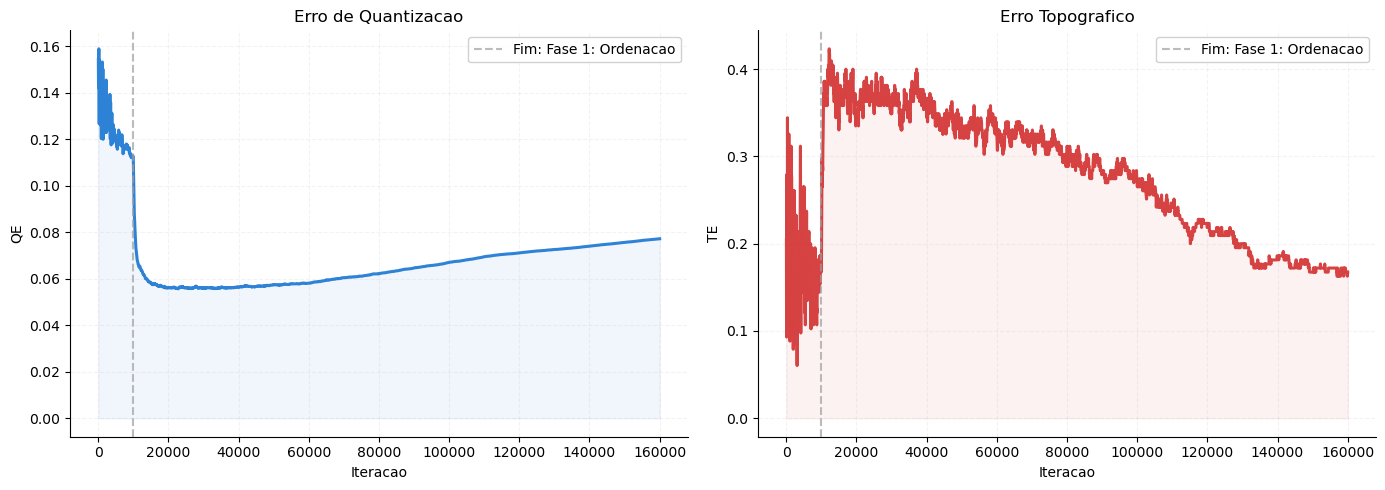

In [5]:
som.plot_training_history()

<Axes: title={'center': 'U-Matrix'}>

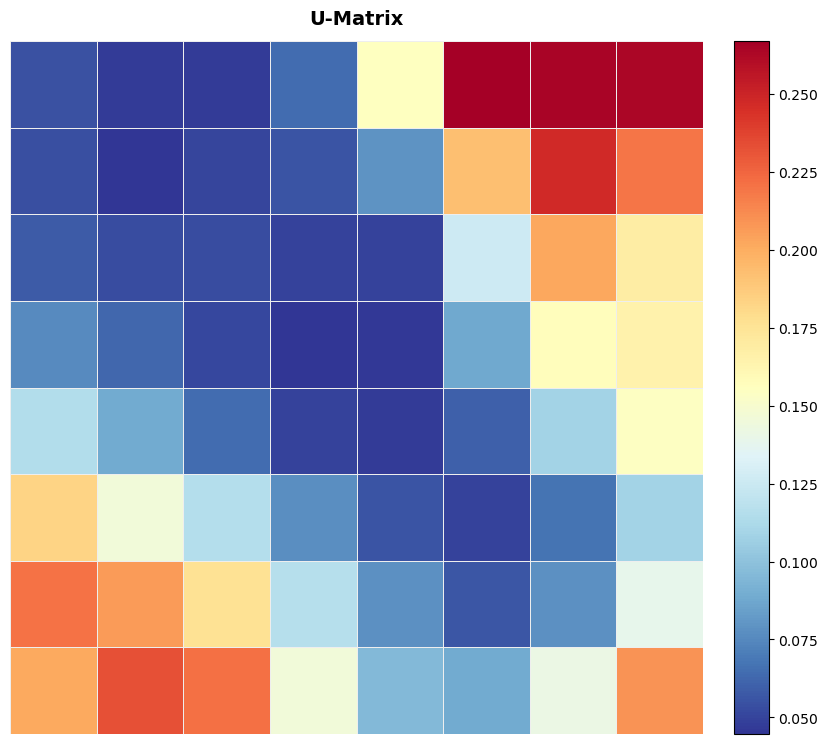

In [6]:
som.plot_umatrix()

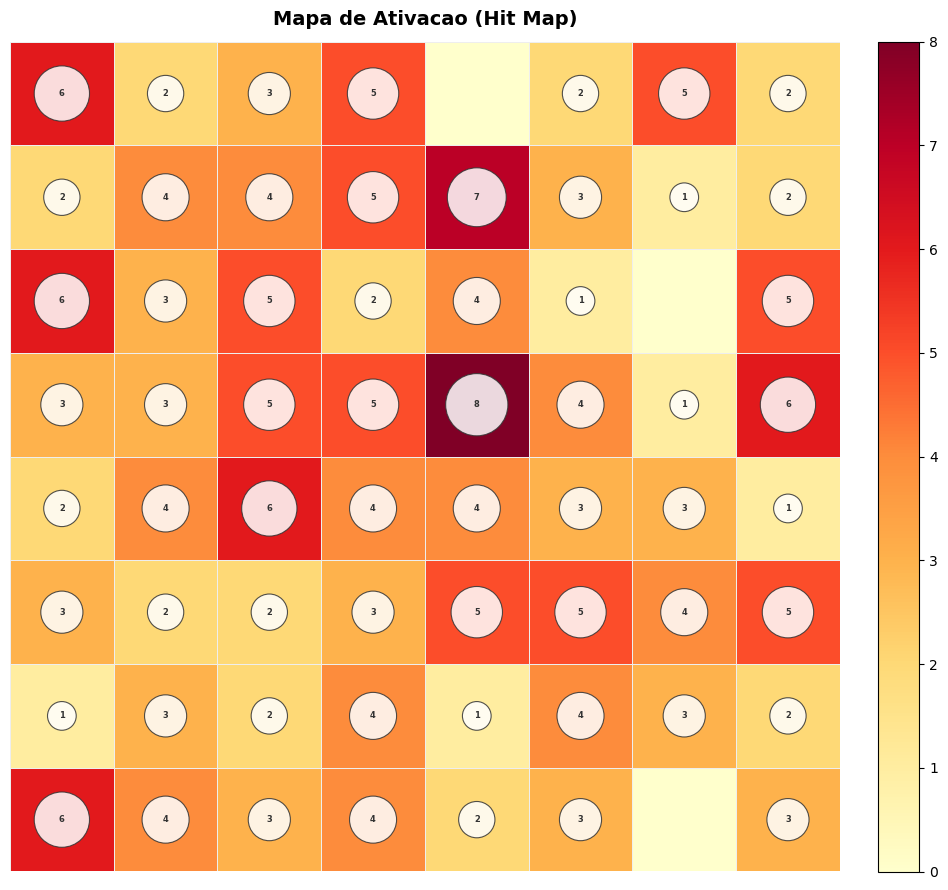

<Axes: title={'center': 'Mapa de Ativacao (Hit Map)'}>

In [7]:
som.plot_hit_map(X_tensor)

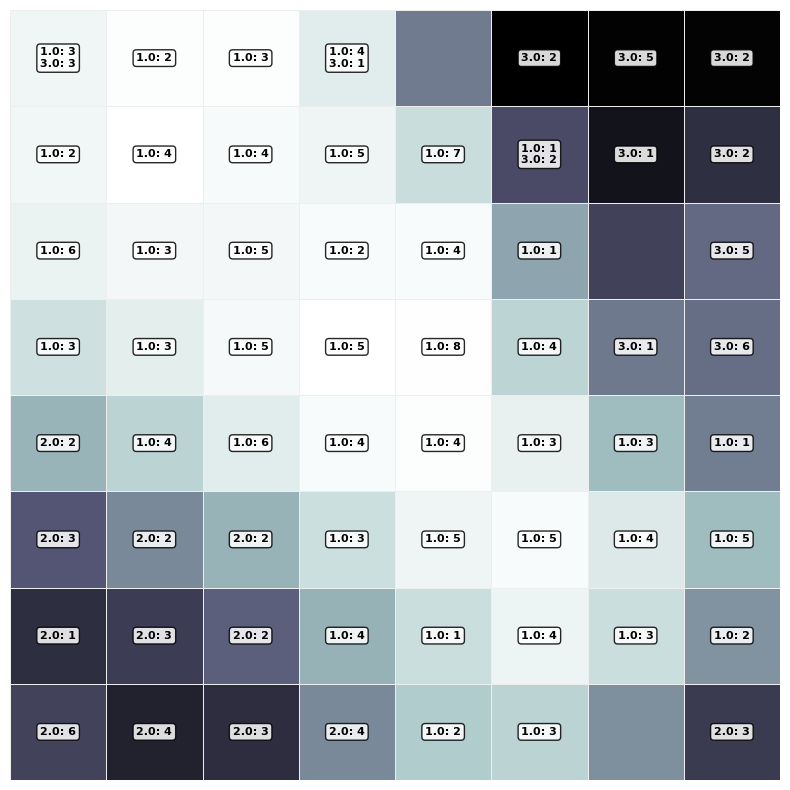

In [8]:
som.plot_label_counts(X_tensor, y)

### Exercício 2: Taxa de Aprendizado Inicial ($\eta$)
Fixe uma topologia e varie apenas o $\eta_{start}$ da fase de ordenação (ex: `0.9`, `0.5`, e `0.05`).
* O que acontece se a taxa for muito alta? E muito baixa?
* Como isso afeta a estabilidade das curvas de erro?



Rascunho

In [9]:
# Seu código aqui



Resposta

### Exercício 3: Raio de Vizinhança ($\sigma$)
Varie o $\sigma_{start}$ (raio inicial). Teste um valor muito pequeno (ex: cobrindo apenas 10% do mapa) e um valor grande (cobrindo 80% do mapa).
* Qual a diferença prática na organização global do mapa (Topographic Error)?



Rascunho

In [10]:
# Seu código aqui



Resposta

### Exercício 4: Topologia e Função de Vizinhança
Teste as topologias (`hexagonal` vs `rectangular`) e as funções de vizinhança (`gaussian` vs `bubble`). Observe especificamente o impacto gerando a **U-Matrix** para cada configuração.
* Qual combinação gera matrizes de distâncias com transições mais suaves?



Rascunho

In [11]:
# Seu código aqui (Treinamentos e U-Matrix)



Resposta

---
## PARTE 2: Modelo Final e Análise Qualitativa

### Exercício 5: Configuração Otimizada e Treinamento Final
Com base nas descobertas dos experimentos anteriores, defina a sua **melhor configuração** de hiperparâmetros.
1. Inicialize e treine o SOM definitivo com esses parâmetros.
2. Aplique o `K-Means` sobre os pesos dos neurônios deste SOM, forçando `K=3` (pois sabemos que existem 3 diagnósticos possíveis para a tireoide).



Rascunho

In [12]:
# Seu código aqui (Treinamento Final e K-Means)



Resposta

### Exercício 6: Análise Qualitativa e Pureza

Agora faça uma avaliação profunda dos resultados obtidos pela melhor configuração:
1. Plote a **U-Matrix**, os **Planos de Componentes** (para investigar quais hormônios influenciam cada área), e o **Mapa de Clusters** (com as fronteiras obtidas pelo K-Means e os rótulos 1.0, 2.0 e 3.0 dos pacientes reais).
2. Construa uma Tabela de Contingência (comparando os 3 clusters do SOM contra as 3 classes reais do dataset).
3. Calcule a **Pureza** de cada cluster e a pureza global.
4. **Responda:** Quais classes de tireoide são bem separadas pelo SOM? Quais se confundem mais? Olhando para os Planos de Componentes, quais hormônios são os maiores responsáveis por separar o Hipertireoidismo do Hipotireoidismo?



Rascunho

In [13]:
# Seu código aqui (Plots, Crosstab, e Análise de Pureza)



Resposta

### Exercício 7: Explorando o agrupamento de forma manual.

Repita o processo realizado nos dois últimos exercícios, desta vez gerando **manualmente** os grupos gerados com base na distância entre neurônios. Responda:

1. Quantos grupos você consegue observar?
2. Quais são as características de cada um desses grupos?

Resposta